# What factors affect the code quality of an AI agent?
##### In other words, does agent or task type affect the average number of issues per pull request?

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# Importing data

prs = pd.read_parquet("hf://datasets/hao-li/AIDev/pull_request.parquet")
ris = pd.read_parquet("hf://datasets/hao-li/AIDev/related_issue.parquet")
tts = pd.read_parquet("hf://datasets/hao-li/AIDev/pr_task_type.parquet")

In [7]:
# Filtering out columns that won't be used

prs = prs[["id", "agent"]]
ris = ris[["pr_id", "issue_id"]]
tts = tts[["id", "type"]]

# Merging the tables [ChatGPT helped]

merged = prs.merge(ris, left_on="id", right_on="pr_id", how="left")[["id", "agent", "issue_id"]]
merged = merged.merge(tts, left_on="id", right_on="id", how="left")[["id", "agent", "type", "issue_id"]]

# Counting issues per pull request [ChatGPT helped]

issues_per_pr = (
    merged.groupby(["id", "agent", "type"])
        .agg(issue_count=("issue_id", "count")) 
        .reset_index()
)

# Grouping issues_per_pr by agent

by_agent = (
    issues_per_pr.groupby("agent")
        .issue_count
        .mean()
        .reset_index(name="issues_per_pr")
        .sort_values("issues_per_pr", ascending=False)
)

# Grouping issues_per_pr by task type

by_type = (
    issues_per_pr.groupby("type")
        .issue_count.mean()
        .reset_index(name="issues_per_pr")
        .sort_values("issues_per_pr", ascending=False)
)

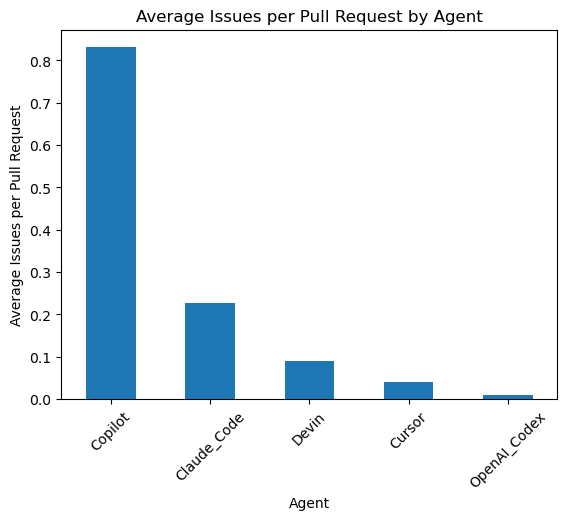

In [8]:
# Plotting Average Issues per Pull Request by Agent

by_agent.plot(kind="bar", x="agent", y="issues_per_pr", legend=False)

plt.title("Average Issues per Pull Request by Agent")
plt.xlabel("Agent")
plt.ylabel("Average Issues per Pull Request")

plt.xticks(rotation=45)
plt.show()

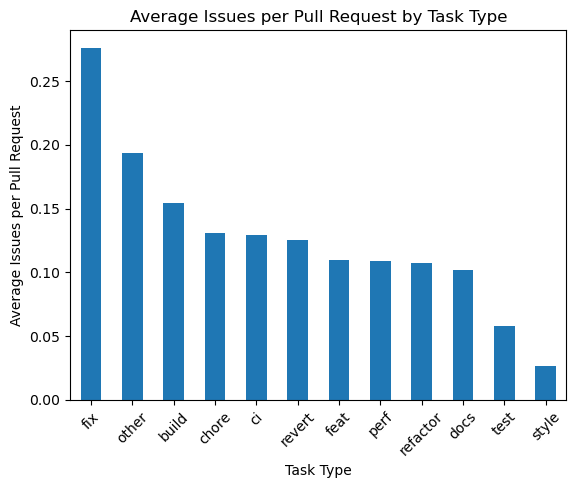

In [9]:
# Plotting Average Issues per Pull Request by Task Type

by_type.plot(kind="bar", x="type", y="issues_per_pr", legend=False)

plt.title("Average Issues per Pull Request by Task Type")
plt.xlabel("Task Type")
plt.ylabel("Average Issues per Pull Request")

plt.xticks(rotation=45)
plt.show()